# Questão E15.9 - Rede do elevador com regra Outstar

Entradas:
- **p⁰** (2×1): código do andar pressionado (ou `[0,0]` se nenhum)
- **p** (3×1): identidade do executivo

Saída: `a = hardlims(W⁰·p⁰ + W·p + b)`

Regra Outstar (por elemento):
$$w_{j}(q) = w_{j}(q-1) + \alpha\,(a_j(q) - w_{j}(q-1))\,p_j(q)$$

Taxa de aprendizado: α = 0,6

In [ ]:
import numpy as np

W0 = np.eye(2) # peso da entrada p⁰ (matriz identidade 2×2)
b = np.array([-0.5, -0.5]) # bias
ALPHA = 0.6 # taxa de aprendizado

FLOOR_CODE = {
    0: np.array([ 0, 0]), # nenhum botão pressionado
    1: np.array([-1, -1]),
    2: np.array([ 1, -1]),
    3: np.array([-1, 1]),
    4: np.array([ 1, 1]),
}

PERSON_VEC = {
    'Presidente': np.array([1, 0, 0]),
    'Vice-Presidente': np.array([0, 1, 0]),
    'Presidente-Conselho': np.array([0, 0, 1]),
}

In [ ]:
def hardlims(n: np.ndarray) -> np.ndarray:
    """Função de ativação: +1 se n >= 0, -1 caso contrário."""

    return np.where(n >= 0, 1, -1)


def network_output(W: np.ndarray, p0: np.ndarray, p: np.ndarray) -> tuple:
    """
    Calcula a saída da rede.

    Parâmetros
    W: matriz de pesos aprendida (2×3)
    p0: código do andar pressionado (2,1)
    p: vetor de identidade do executivo (3,1)

    Retorna
    n: entrada líquida (2,1)
    a: saída após hardlims (2,1)
    """

    n = W0 @ p0 + W @ p + b
    a = hardlims(n)
    return n, a


def outstar_update(W: np.ndarray, a: np.ndarray, p: np.ndarray, alpha: float = ALPHA) -> np.ndarray:
    """
    Atualiza W pela regra Outstar.

    Parâmetros
    W: pesos atuais (2×3)
    a: saída da rede nesta iteração (2,1)
    p: vetor de identidade do executivo (3,1)
    alpha: taxa de aprendizado

    Retorna
    W_new : pesos atualizados (2×3)
    """

    W_new = W.copy()
    for j in range(W.shape[0]): # para cada saída (linha)
        for k in range(W.shape[1]):  # para cada entrada (coluna)
            W_new[j, k] = W[j, k] + alpha * (a[j] - W[j, k]) * p[k]

    return W_new

In [ ]:
def train(sequence: list, W_init: np.ndarray = None, alpha: float = ALPHA, verbose: bool = True) -> np.ndarray:
    """
    Treina a rede na sequência fornecida.

    Parâmetros
    sequence: lista de dicts com chaves 'floor' (int) e 'person' (str)
    W_init: pesos iniciais (2×3); padrão = zeros
    alpha: taxa de aprendizado
    verbose: imprime detalhes de cada iteração

    Retorna
    W : pesos finais (2×3)
    """

    W = np.zeros((2, 3)) if W_init is None else W_init.copy()

    for q, step in enumerate(sequence, start=1):
        floor = step['floor']
        person = step['person']
        p0 = FLOOR_CODE[floor]
        p = PERSON_VEC[person]

        n, a = network_output(W, p0, p)
        W_new = outstar_update(W, a, p, alpha)

        if verbose:
            print(f'Iteração {q}: {person} → Andar {floor}')
            print(f'p⁰ = {p0}   p = {p}')
            print(f'n = {np.round(n, 4)}')
            print(f'a = {a}   (código andar {floor}: {FLOOR_CODE[floor]})')
            print(f'\nW anterior:\n{np.round(W, 4)}')
            print(f'\nW novo:\n{np.round(W_new, 4)}\n\n')

        W = W_new

    if verbose:
        print(f'\nW final:\n{np.round(W, 4)}')

    return W

i. A seguir, faremos o treinamento com os 6 passos fornecidos no enunciado.

In [ ]:
# {p⁰=p4, p=p1}, {p⁰=p3, p=p2}, {p⁰=p1, p=p3},
# {p⁰=p3, p=p2}, {p⁰=p2, p=p3}, {p⁰=p4, p=p1}

sequence_i = [
    {'floor': 4, 'person': 'Presidente'},
    {'floor': 3, 'person': 'Vice-Presidente'},
    {'floor': 3, 'person': 'Vice-Presidente'},
    {'floor': 2, 'person': 'Presidente-Conselho'},
    {'floor': 4, 'person': 'Presidente'},
    {'floor': 2, 'person': 'Presidente-Conselho'},
]

W_final = train(sequence_i)

Iteração 1: Presidente → Andar 4
p⁰ = [1 1]   p = [1 0 0]
n = [0.5 0.5]
a = [1 1]   (código andar 4: [1 1])

W anterior:
[[0. 0. 0.]
 [0. 0. 0.]]

W novo:
[[0.6 0.  0. ]
 [0.6 0.  0. ]]


Iteração 2: Vice-Presidente → Andar 3
p⁰ = [-1  1]   p = [0 1 0]
n = [-1.5  0.5]
a = [-1  1]   (código andar 3: [-1  1])

W anterior:
[[0.6 0.  0. ]
 [0.6 0.  0. ]]

W novo:
[[ 0.6 -0.6  0. ]
 [ 0.6  0.6  0. ]]


Iteração 3: Vice-Presidente → Andar 3
p⁰ = [-1  1]   p = [0 1 0]
n = [-2.1  1.1]
a = [-1  1]   (código andar 3: [-1  1])

W anterior:
[[ 0.6 -0.6  0. ]
 [ 0.6  0.6  0. ]]

W novo:
[[ 0.6  -0.84  0.  ]
 [ 0.6   0.84  0.  ]]


Iteração 4: Presidente-Conselho → Andar 2
p⁰ = [ 1 -1]   p = [0 0 1]
n = [ 0.5 -1.5]
a = [ 1 -1]   (código andar 2: [ 1 -1])

W anterior:
[[ 0.6  -0.84  0.  ]
 [ 0.6   0.84  0.  ]]

W novo:
[[ 0.6  -0.84  0.6 ]
 [ 0.6   0.84 -0.6 ]]


Iteração 5: Presidente → Andar 4
p⁰ = [1 1]   p = [1 0 0]
n = [1.1 1.1]
a = [1 1]   (código andar 4: [1 1])

W anterior:
[[ 0.6  -0.84  0.6

ii. Como visto ao final do treinamento, os pesos finais foram:

$$W final^ = \begin{bmatrix} 0.84 & -0.84 & 0.84 \\ 0.84 & 0.84 & -0.84 \end{bmatrix}$$


iii. O enunciado pede para fazermos uma simulação de três eventos: nem o Presidente, nem o Vice-Presidente e nem o Presidente-Conselho pressionam um botão.

In [ ]:
print('Teste onde não há botões pressionados\n')

p0_none = FLOOR_CODE[0]

floor_from_code = {tuple(v): k for k, v in FLOOR_CODE.items() if k != 0}

for person, p in PERSON_VEC.items():
    _, a = network_output(W_final, p0_none, p)
    andar = floor_from_code.get(tuple(a), '?')
    print(f'  {person:20s} → a = {a}  → Andar predito: {andar}')

Teste onde não há botões pressionados

  Presidente           → a = [1 1]  → Andar predito: 4
  Vice-Presidente      → a = [-1  1]  → Andar predito: 3
  Presidente-Conselho  → a = [ 1 -1]  → Andar predito: 2


iv. A rede levou os executivos para os seguintes andares:

| Executivo              | Andar predito|
|------------------------|--------------|
| Presidente             | 4            |
| Vice-Presidente        | 3            |
| Presidente do Conselho | 2            |


v. E se os executivos apertarem outros botões muitas vezes?

Como p é *one-hot*, cada coluna de W converge independentemente para o
código do novo andar favorito daquele executivo:

| Coluna | Executivo | Andar | Código esperado |
|--------|-----------|-------|-----------------|
| 1 | Presidente | 3 | `[-1, 1]` |
| 2 | Vice-Presidente | 2 | `[1, -1]` |
| 3 | Presidente do Conselho | 4 | `[1, 1]` |

Portanto, W* esperado:
$$W^* = \begin{bmatrix} -1 & 1 & 1 \\ 1 & -1 & 1 \end{bmatrix}$$

Vamos verificar isso simulando repetições até a convergência.

In [ ]:
def train_until_convergence(base_sequence: list, W_init: np.ndarray = None, alpha: float = ALPHA, tol: float = 1e-6, max_epochs: int = 500) -> tuple:
    """
    Repete base_sequence em épocas até W parar de mudar (||ΔW|| < tol).

    Retorna
    W: pesos convergidos
    epochs: número de épocas até convergência
    history: lista com a norma de ΔW a cada época
    """

    W = np.zeros((2, 3)) if W_init is None else W_init.copy()
    history = []

    for epoch in range(1, max_epochs + 1):
        W_before = W.copy()
        W = train(base_sequence, W_init=W, alpha=alpha, verbose=False)
        delta = np.linalg.norm(W - W_before)
        history.append(delta)

        if delta < tol:
            return W, epoch, history

    print(f'Aviso: não convergiu em {max_epochs} épocas.')
    return W, max_epochs, history

sequence_v = [
    {'floor': 3, 'person': 'Presidente'},
    {'floor': 2, 'person': 'Vice-Presidente'},
    {'floor': 4, 'person': 'Presidente-Conselho'},
]

W_v, epochs, history = train_until_convergence(sequence_v)

print(f'Convergiu em {epochs} época(s).\n')
print(f'W convergido:\n{np.round(W_v, 6)}\n')
print(f'W* esperado analiticamente:')
print(np.array([[-1, 1, 1],
                [ 1,-1, 1]], dtype=float))

Convergiu em 17 época(s).

W convergido:
[[-1.  1.  1.]
 [ 1. -1.  1.]]

W* esperado analiticamente:
[[-1.  1.  1.]
 [ 1. -1.  1.]]


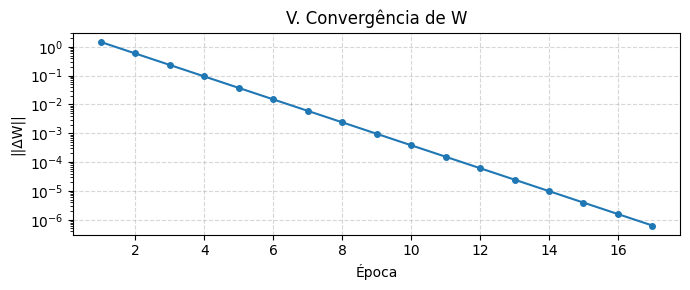

In [ ]:
# curva de convergência
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3))
plt.plot(range(1, len(history) + 1), history, marker='o', markersize=4)
plt.xlabel('Época')
plt.ylabel('||ΔW||')
plt.title('V. Convergência de W')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Fazemos uma verificação para ver se os executivos são levados aos novos andares favoritos:

In [ ]:
print('\nPredição com W convergido (sem botão pressionado):')
floor_from_code = {tuple(v): k for k, v in FLOOR_CODE.items() if k != 0}
p0_none = FLOOR_CODE[0]

for person, p in PERSON_VEC.items():
    _, a = network_output(W_v, p0_none, p)
    andar = floor_from_code.get(tuple(a), '?')

    print(f'  {person:20s} → a = {a}  → Andar predito: {andar}')


Predição com W convergido (sem botão pressionado):
  Presidente           → a = [-1  1]  → Andar predito: 3
  Vice-Presidente      → a = [ 1 -1]  → Andar predito: 2
  Presidente-Conselho  → a = [1 1]  → Andar predito: 4
